In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [59]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA A100-SXM4-80GB


In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
print(device)

torch.backends.cudnn.benchmark = True

cuda


Download Dataset

In [61]:


! pip install opendatasets

import opendatasets as od

od.download('https://www.kaggle.com/datasets/anggadwisunarto/text-deblurring-dataset-with-psf-for-ocr')

Skipping, found downloaded files in "./text-deblurring-dataset-with-psf-for-ocr" (use force=True to force download)


check folder structure

In [62]:
import os

root_base = "/content/text-deblurring-dataset-with-psf-for-ocr"

print(f"Contents of {root_base}:")
print(os.listdir(root_base))

# Assuming 'BMVC_image_data' is the correct folder, you would uncomment and modify the line below:
# root = os.path.join(root_base, "BMVC_image_data")
# print(os.listdir(root))
# print(os.listdir(os.path.join(root, "blur")))

Contents of /content/text-deblurring-dataset-with-psf-for-ocr:
['BMVC_OCR_test_data', 'BMVC_image_quality_test_data', 'BMVC_image_data']


In [63]:
root_base = "/content/text-deblurring-dataset-with-psf-for-ocr"
print(os.listdir(root_base))

['BMVC_OCR_test_data', 'BMVC_image_quality_test_data', 'BMVC_image_data']


In [64]:
import os

root = "/content/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data"

print(os.listdir(root))
print(os.listdir(os.path.join(root, "blur")))

['psf', 'orig', 'blur']
['0028883_blur.png', '0043073_blur.png', '0010003_blur.png', '0011233_blur.png', '0032481_blur.png', '0016017_blur.png', '0035990_blur.png', '0038776_blur.png', '0036945_blur.png', '0064635_blur.png', '0052069_blur.png', '0040966_blur.png', '0010560_blur.png', '0039781_blur.png', '0033230_blur.png', '0041200_blur.png', '0027039_blur.png', '0021989_blur.png', '0025295_blur.png', '0038110_blur.png', '0040786_blur.png', '0062002_blur.png', '0004231_blur.png', '0037486_blur.png', '0032245_blur.png', '0021917_blur.png', '0052947_blur.png', '0065086_blur.png', '0060392_blur.png', '0028067_blur.png', '0005436_blur.png', '0009383_blur.png', '0025643_blur.png', '0024351_blur.png', '0056065_blur.png', '0022881_blur.png', '0042468_blur.png', '0048197_blur.png', '0001506_blur.png', '0030496_blur.png', '0065818_blur.png', '0002726_blur.png', '0065548_blur.png', '0058204_blur.png', '0025588_blur.png', '0006314_blur.png', '0032214_blur.png', '0037189_blur.png', '0047219_blur.p

In [65]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'text-deblurring-dataset-with-psf-for-ocr', 'sample_data']


check data location

In [66]:
!find / -maxdepth 4 -iname "BMVC_image_data" 2>/dev/null

/content/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data


Transform

In [67]:
'''transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])'''
transform = transforms.Compose([
    transforms.Resize((256, 256), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor()
])

create dataset using all blur folders






In [68]:
from torch.utils.data import Dataset
from PIL import Image
import os

class DeblurDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.orig_dir = os.path.join(root_dir, "orig")
        self.blur_dir = os.path.join(root_dir, "blur")
        self.samples = []

        # Build a lookup: ID -> orig filename
        orig_files = os.listdir(self.orig_dir)
        orig_lookup = {f.split("_")[0]: f for f in orig_files}

        blur_files = sorted(os.listdir(self.blur_dir))
        for blur_fname in blur_files:
            file_id = blur_fname.split("_")[0]  # e.g. "0023642"
            if file_id in orig_lookup:
                blur_path = os.path.join(self.blur_dir, blur_fname)
                clear_path = os.path.join(self.orig_dir, orig_lookup[file_id])
                self.samples.append((blur_path, clear_path))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        blur_path, clear_path = self.samples[idx]
        blur = Image.open(blur_path).convert("RGB")
        clear = Image.open(clear_path).convert("RGB")
        if self.transform:
            blur = self.transform(blur)
            clear = self.transform(clear)
        return blur, clear

In [69]:
import torch
from tqdm import tqdm

def build_cache(dataset, save_path):
    blurs, clears = [], []
    for i in tqdm(range(len(dataset))):
        b, c = dataset[i]
        blurs.append(b)
        clears.append(c)
    blurs = torch.stack(blurs)
    clears = torch.stack(clears)
    torch.save({'blur': blurs, 'clear': clears}, save_path)
    print("Saved cache:", save_path, blurs.shape)

create dataset

In [70]:
dataset = DeblurDataset(
    root_dir="/content/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_data",  # ← replace with YOUR path from Cell 1
    transform=transform
)

print("Total samples:", len(dataset))

Total samples: 66742


In [71]:
!find /content/text-deblurring-dataset-with-psf-for-ocr -maxdepth 5 -iname "n_00"

/content/text-deblurring-dataset-with-psf-for-ocr/BMVC_OCR_test_data/n_00
/content/text-deblurring-dataset-with-psf-for-ocr/BMVC_image_quality_test_data/n_00


In [72]:
import random

random.seed(42)
sample_size = 30000
dataset.samples = random.sample(dataset.samples, sample_size)
print("Subsampled to:", len(dataset.samples))

Subsampled to: 30000


split the dataset

In [73]:
from torch.utils.data import random_split

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Train:", len(train_dataset), "| Val:", len(val_dataset))

Train: 24000 | Val: 6000


Data Loader

In [74]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

Check batch


In [75]:
blur, clear = next(iter(train_loader))

print(blur.shape)
print(clear.shape)

torch.Size([16, 3, 256, 256])
torch.Size([16, 3, 256, 256])


Define U Net model

In [76]:
class UNetDeblur(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.out = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetDeblur().to(device)
print(device)

cuda


In [77]:
'''class UNetDeblur(nn.Module):
    def __init__(self):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(3, 64)
        self.enc2 = conv_block(64, 128)
        self.enc3 = conv_block(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = conv_block(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = conv_block(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.out = nn.Conv2d(64, 3, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.clamp(x + self.out(d1), 0, 1)   # residual learning


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetDeblur().to(device)
print(device)'''

'class UNetDeblur(nn.Module):\n    def __init__(self):\n        super().__init__()\n        def conv_block(in_c, out_c):\n            return nn.Sequential(\n                nn.Conv2d(in_c, out_c, 3, padding=1),\n                nn.BatchNorm2d(out_c),\n                nn.ReLU(inplace=True),\n                nn.Conv2d(out_c, out_c, 3, padding=1),\n                nn.BatchNorm2d(out_c),\n                nn.ReLU(inplace=True)\n            )\n\n        self.enc1 = conv_block(3, 64)\n        self.enc2 = conv_block(64, 128)\n        self.enc3 = conv_block(128, 256)\n        self.pool = nn.MaxPool2d(2)\n\n        self.bottleneck = conv_block(256, 512)\n\n        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)\n        self.dec3 = conv_block(512, 256)\n        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)\n        self.dec2 = conv_block(256, 128)\n        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)\n        self.dec1 = conv_block(128, 64)\n\n        self.out = nn.Conv2d(64, 

 Loss, optimizer, scheduler

In [78]:
'''import torch.optim as optim

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 35  # decide this NOW, since scheduler depends on it

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)'''

'import torch.optim as optim\n\ncriterion = nn.L1Loss()\noptimizer = optim.Adam(model.parameters(), lr=1e-4)\n\nnum_epochs = 35  # decide this NOW, since scheduler depends on it\n\nscheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)'

In [79]:
import torch.optim as optim

def sobel_edges(img):
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32, device=img.device)
    ky = kx.t()
    kx = kx.view(1,1,3,3).repeat(3,1,1,1)
    ky = ky.view(1,1,3,3).repeat(3,1,1,1)
    gx = F.conv2d(img, kx, padding=1, groups=3)
    gy = F.conv2d(img, ky, padding=1, groups=3)
    return torch.sqrt(gx**2 + gy**2 + 1e-6)

criterion_l1 = nn.L1Loss()
def combined_loss(pred, target):
    l1 = criterion_l1(pred, target)
    edge = criterion_l1(sobel_edges(pred), sobel_edges(target))
    return l1 + 0.5 * edge

optimizer = optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 35
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

PSNR/SSIM helper functions

In [80]:
import numpy as np
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_metrics(pred, target):
    pred = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
    target = target.detach().cpu().numpy().transpose(0, 2, 3, 1)
    psnr_total, ssim_total = 0, 0
    for p, t in zip(pred, target):
        psnr_total += psnr(t, p, data_range=1.0)
        ssim_total += ssim(t, p, data_range=1.0, channel_axis=2)
    return psnr_total / len(pred), ssim_total / len(pred)

In [81]:
def fast_psnr(pred, target, data_range=1.0):
    mse = torch.mean((pred - target) ** 2, dim=[1, 2, 3])
    val = 10 * torch.log10((data_range ** 2) / (mse + 1e-8))
    return val.mean().item()

In [82]:
'''import torch

def gpu_psnr(pred, target, data_range=1.0):
    mse = torch.mean((pred - target) ** 2, dim=[1, 2, 3])
    psnr = 10 * torch.log10((data_range ** 2) / (mse + 1e-8))
    return psnr.mean().item()'''

'import torch\n\ndef gpu_psnr(pred, target, data_range=1.0):\n    mse = torch.mean((pred - target) ** 2, dim=[1, 2, 3])\n    psnr = 10 * torch.log10((data_range ** 2) / (mse + 1e-8))\n    return psnr.mean().item()'

In [83]:
'''from skimage.metrics import structural_similarity as ssim

def compute_ssim_only(pred, target):
    pred = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
    target = target.detach().cpu().numpy().transpose(0, 2, 3, 1)
    total = 0
    for p, t in zip(pred, target):
        total += ssim(t, p, data_range=1.0, channel_axis=2)
    return total / len(pred)'''

'from skimage.metrics import structural_similarity as ssim\n\ndef compute_ssim_only(pred, target):\n    pred = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)\n    target = target.detach().cpu().numpy().transpose(0, 2, 3, 1)\n    total = 0\n    for p, t in zip(pred, target):\n        total += ssim(t, p, data_range=1.0, channel_axis=2)\n    return total / len(pred)'

In [84]:
'''import torch.nn.functional as F

sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3).to(device)
sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32).view(1,1,3,3).to(device)

def edge_loss(pred, target):
    # convert to grayscale for edge detection
    pred_gray = pred.mean(dim=1, keepdim=True)
    target_gray = target.mean(dim=1, keepdim=True)

    pred_gx = F.conv2d(pred_gray, sobel_x, padding=1)
    pred_gy = F.conv2d(pred_gray, sobel_y, padding=1)
    target_gx = F.conv2d(target_gray, sobel_x, padding=1)
    target_gy = F.conv2d(target_gray, sobel_y, padding=1)

    return F.l1_loss(pred_gx, target_gx) + F.l1_loss(pred_gy, target_gy)'''

'import torch.nn.functional as F\n\nsobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3).to(device)\nsobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32).view(1,1,3,3).to(device)\n\ndef edge_loss(pred, target):\n    # convert to grayscale for edge detection\n    pred_gray = pred.mean(dim=1, keepdim=True)\n    target_gray = target.mean(dim=1, keepdim=True)\n\n    pred_gx = F.conv2d(pred_gray, sobel_x, padding=1)\n    pred_gy = F.conv2d(pred_gray, sobel_y, padding=1)\n    target_gx = F.conv2d(target_gray, sobel_x, padding=1)\n    target_gy = F.conv2d(target_gray, sobel_y, padding=1)\n\n    return F.l1_loss(pred_gx, target_gx) + F.l1_loss(pred_gy, target_gy)'

Training loop with checkpointing to Drive

In [85]:
import os
import time
import torch
from torch.cuda.amp import autocast, GradScaler

checkpoint_dir = "/content/drive/MyDrive/text_deblur_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

scaler = GradScaler()
best_psnr = 0
patience = 5
bad_epochs = 0
grad_clip_norm = 1.0

for epoch in range(num_epochs):
    t0 = time.time()

    model.train()
    train_loss = 0
    for blur, clear in train_loader:
        blur, clear = blur.to(device, non_blocking=True), clear.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast():
            output = model(blur)
            loss = combined_loss(output, clear)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    scheduler.step()
    avg_train_loss = train_loss / len(train_loader)

    model.eval()
    val_loss = 0
    val_psnr_fast = 0
    val_psnr, val_ssim = 0, 0
    compute_full_metrics = (epoch + 1) % 2 == 0 or epoch == num_epochs - 1

    with torch.no_grad():
        for blur, clear in val_loader:
            blur, clear = blur.to(device, non_blocking=True), clear.to(device, non_blocking=True)
            with autocast():
                output = model(blur)
                loss = combined_loss(output, clear)
            val_loss += loss.item()

            val_psnr_fast += fast_psnr(output.float(), clear.float())

            if compute_full_metrics:
                p, s = compute_metrics(output.float(), clear.float())
                val_psnr += p
                val_ssim += s

    avg_val_loss = val_loss / len(val_loader)
    avg_val_psnr_fast = val_psnr_fast / len(val_loader)
    epoch_time = time.time() - t0

    if compute_full_metrics:
        avg_val_psnr = val_psnr / len(val_loader)
        avg_val_ssim = val_ssim / len(val_loader)
        print(f"Epoch {epoch+1}/{num_epochs} | {epoch_time:.1f}s | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | PSNR: {avg_val_psnr:.2f} | SSIM: {avg_val_ssim:.4f}")

        if avg_val_psnr > best_psnr:
            best_psnr = avg_val_psnr
            bad_epochs = 0
            torch.save(model.state_dict(), os.path.join(checkpoint_dir, "best.pth"))
            print(f"  ↳ New best model saved (PSNR: {best_psnr:.2f})")
        else:
            bad_epochs += 1
    else:
        print(f"Epoch {epoch+1}/{num_epochs} | {epoch_time:.1f}s | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | fast-PSNR: {avg_val_psnr_fast:.2f}")

    if (epoch + 1) % 5 == 0 or epoch == num_epochs - 1:
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, "latest.pth"))

    if bad_epochs >= patience:
        print(f"No PSNR improvement for {patience} checks -> stopping early at epoch {epoch+1}.")
        break

/tmp/ipykernel_4503/3100791607.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_4503/3100791607.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_4503/3100791607.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1/35 | 112.8s | Train Loss: 0.2645 | Val Loss: 0.1595 | fast-PSNR: 19.81
Epoch 2/35 | 184.4s | Train Loss: 0.1418 | Val Loss: 0.1315 | PSNR: 21.23 | SSIM: 0.8798
  ↳ New best model saved (PSNR: 21.23)
Epoch 3/35 | 112.4s | Train Loss: 0.1206 | Val Loss: 0.1134 | fast-PSNR: 22.46
Epoch 4/35 | 182.1s | Train Loss: 0.1094 | Val Loss: 0.1027 | PSNR: 23.48 | SSIM: 0.9207
  ↳ New best model saved (PSNR: 23.48)
Epoch 5/35 | 112.6s | Train Loss: 0.1025 | Val Loss: 0.0991 | fast-PSNR: 23.91
Epoch 6/35 | 183.3s | Train Loss: 0.0974 | Val Loss: 0.0957 | PSNR: 24.37 | SSIM: 0.9302
  ↳ New best model saved (PSNR: 24.37)
Epoch 7/35 | 112.9s | Train Loss: 0.0938 | Val Loss: 0.0954 | fast-PSNR: 24.22
Epoch 8/35 | 182.3s | Train Loss: 0.0907 | Val Loss: 0.0914 | PSNR: 24.81 | SSIM: 0.9361
  ↳ New best model saved (PSNR: 24.81)
Epoch 9/35 | 112.8s | Train Loss: 0.0881 | Val Loss: 0.0881 | fast-PSNR: 24.93
Epoch 10/35 | 182.9s | Train Loss: 0.0859 | Val Loss: 0.0868 | PSNR: 25.27 | SSIM: 0.9407
  ↳

check image

In [86]:
import os

dataset_root = "/content/drive/MyDrive/text-deblurring-dataset-with-ps..."  # replace with exact folder name
for root, dirs, files in os.walk(dataset_root):
    for f in files[:5]:  # just show a few per folder
        print(os.path.join(root, f))

In [88]:
import os
print(os.path.exists("/content/drive/MyDrive/text_deblur_checkpoints/best.pth"))

True


In [89]:
from google.colab import files
files.download("/content/drive/MyDrive/text_deblur_checkpoints/best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving 0000005_blur.png to 0000005_blur.png


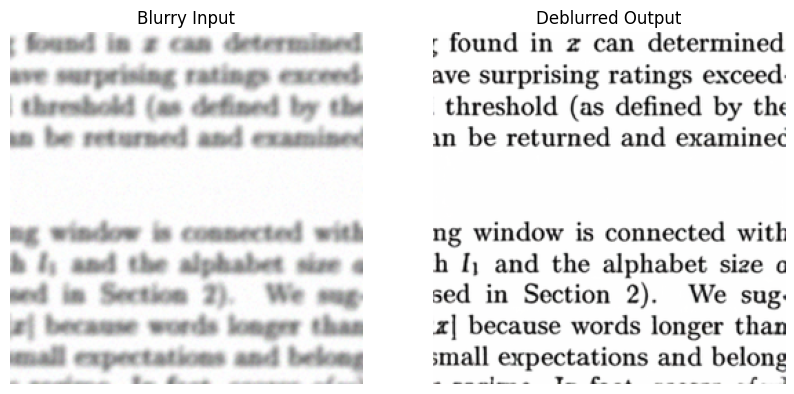

Saved to /content/deblurred_result.jpg


In [114]:
import os
import torch
from PIL import Image
from torchvision import transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
from google.colab import files

# ---- 1. Load the BEST trained weights ----
model = UNetDeblur().to(device)
model.load_state_dict(torch.load(
    os.path.join(checkpoint_dir, "best.pth"),
    map_location=device
))
model.eval()

# ---- 2. Preprocessing ----
infer_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = infer_transform(img).unsqueeze(0)
    return img, tensor.to(device)

# ---- 3. Run inference ----
def deblur_image(path):
    blurry_img, input_tensor = load_image(path)
    with torch.no_grad():
        output = model(input_tensor)
    output_img = output.squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1).numpy()
    return blurry_img, output_img

# ---- 4. Upload your own blurry image ----
uploaded = files.upload()
image_path = list(uploaded.keys())[0]  # gets the uploaded file's name/path

blurry_img, result = deblur_image(image_path)

# ---- 5. Show blurry vs clear side by side ----
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(blurry_img.resize((256, 256)))
axes[0].set_title("Blurry Input")
axes[0].axis("off")

axes[1].imshow(result)
axes[1].set_title("Deblurred Output")
axes[1].axis("off")
plt.show()

# ---- 6. Save the deblurred output to disk ----
output_tensor = torch.from_numpy(result).permute(2, 0, 1)
save_image(output_tensor, "/content/deblurred_result.jpg")
print("Saved to /content/deblurred_result.jpg")

In [94]:
from google.colab import files
files.download("/content/drive/MyDrive/text_deblur_checkpoints/best.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>